# 09. Preparación de Datos — Iteración 6: Incorporación de Descuentos Promocionales

## El problema de la granularidad

Antes de modelar, tenemos un reto técnico que resolver: **los datos de descuentos viven en un dataset con una granularidad distinta al que alimenta el modelo**.

| Dataset | Granularidad | Nº filas |
|---|---|---|
| `Dataset_España_base.csv` | Una fila por **transacción** (albarán individual) | 597.371 |
| `df_final_modelado.csv` | Una fila por **semana × municipio × artículo** | 252.836 |

Un mismo artículo en un mismo municipio durante la misma semana puede tener **varias transacciones** (varios albaranes a distintos clientes). Cada una puede tener su propio descuento promocional.

Para incorporar `por_descuento2` al modelo necesitamos **agregar** esas múltiples transacciones a una sola fila por semana × municipio × artículo.

## ¿Qué variables crearemos?

De `por_descuento2` extraeremos dos señales complementarias:

| Variable nueva | Tipo | Qué captura |
|---|---|---|
| `hubo_descuento_promo` | Binaria (0/1) | ¿Hubo alguna promoción esa semana para ese artículo en ese municipio? |
| `valor_descuento_promo` | Numérica (0–15) | ¿Cuánto fue el descuento máximo aplicado? (0 si no hubo promoción) |

La variable **binaria** le dice al modelo si hubo evento promocional. La variable **numérica** le dice además la intensidad: no es lo mismo un 2% que un 15% de descuento.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE = sns.color_palette('muted')

print('Librerías cargadas.')

Librerías cargadas.


---
## 1. Carga de los dos datasets

Cargamos ambos datasets y confirmamos sus dimensiones y estructura antes de tocar nada.

In [2]:
# Dataset de transacciones originales (granularidad: albarán)
df_base = pd.read_csv('../Datasets/Dataset_España_base.csv', sep=';', low_memory=False)

# Dataset de modelado (granularidad: semana × municipio × artículo)
df_modelo = pd.read_csv('../Datasets/df_final_modelado.csv', sep=';')

print('=== DATASET BASE (transacciones) ===')
print(f'Shape: {df_base.shape}')
print(f'Años disponibles: {sorted(df_base["anio"].unique())}')
print(f'Columnas descuento: por_descuento, por_descuento2')

print('\n=== DATASET MODELADO (semanal agregado) ===')
print(f'Shape: {df_modelo.shape}')
print(f'Años disponibles: {sorted(df_modelo["anio"].unique())}')
print(f'Columnas: {list(df_modelo.columns)}')

=== DATASET BASE (transacciones) ===
Shape: (597371, 31)
Años disponibles: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Columnas descuento: por_descuento, por_descuento2

=== DATASET MODELADO (semanal agregado) ===
Shape: (252836, 19)
Años disponibles: [np.int64(2022), np.int64(2023), np.int64(2024)]
Columnas: ['anio', 'semana_anio', 'Provincia', 'Municipio', 'codigo_articulo', 'unidades', 'importe_neto', 'tipo_abc', 'CodigoFamilia', 'CodigoSubfamilia', 'agrupacion_canal', 'unidades_lag_1_semana', 'unidades_lag_1_mes', 'num_pruebas_ciclistas', 'duracion_total_pruebas', 'hubo_prueba_ciclista', 'temp_media', 'precip_mm', 'viento_max']


---
## 2. Análisis exploratorio de `por_descuento2`

### ¿Qué es `por_descuento2`?

A diferencia de `por_descuento` (el descuento comercial estándar que tiene **todos** los albaranes), `por_descuento2` es un **descuento adicional y excepcional**: solo aparece cuando hay una acción comercial especial (promoción, campaña, oferta por volumen).

Antes de agregarlo, entendamos bien su distribución y su impacto real en la demanda.

In [3]:
# Filtrar solo los años del modelo (2022-2024)
df_base_22_24 = df_base[df_base['anio'].isin([2022, 2023, 2024])].copy()
print(f'Transacciones 2022-2024: {len(df_base_22_24):,}')

print(f'\n--- por_descuento (descuento comercial estándar) ---')
print(df_base_22_24['por_descuento'].describe().round(2))
print(f'Filas con por_descuento > 0: {(df_base_22_24["por_descuento"] > 0).sum():,} '
      f'({(df_base_22_24["por_descuento"] > 0).mean()*100:.1f}%)')

print(f'\n--- por_descuento2 (descuento promocional) ---')
print(df_base_22_24['por_descuento2'].describe().round(4))
print(f'Filas con por_descuento2 > 0: {(df_base_22_24["por_descuento2"] > 0).sum():,} '
      f'({(df_base_22_24["por_descuento2"] > 0).mean()*100:.2f}%)')
print(f'Valores únicos de por_descuento2: {sorted(df_base_22_24["por_descuento2"].unique())}')

Transacciones 2022-2024: 291,802

--- por_descuento (descuento comercial estándar) ---
count    291802.00
mean         39.38
std          12.16
min           0.00
25%          35.00
50%          45.00
75%          45.00
max          54.00
Name: por_descuento, dtype: float64
Filas con por_descuento > 0: 273,818 (93.8%)

--- por_descuento2 (descuento promocional) ---
count    291802.0000
mean          0.0777
std           0.7110
min           0.0000
25%           0.0000
50%           0.0000
75%           0.0000
max          15.0000
Name: por_descuento2, dtype: float64
Filas con por_descuento2 > 0: 3,834 (1.31%)
Valores únicos de por_descuento2: [np.float64(0.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(8.0), np.float64(10.0), np.float64(15.0)]


Media unidades SIN promoción: 1.434
Media unidades CON promoción: 6.573
Multiplicador de demanda:     4.59x

Promocioness por año:
anio
2022     794
2023    1771
2024    1269


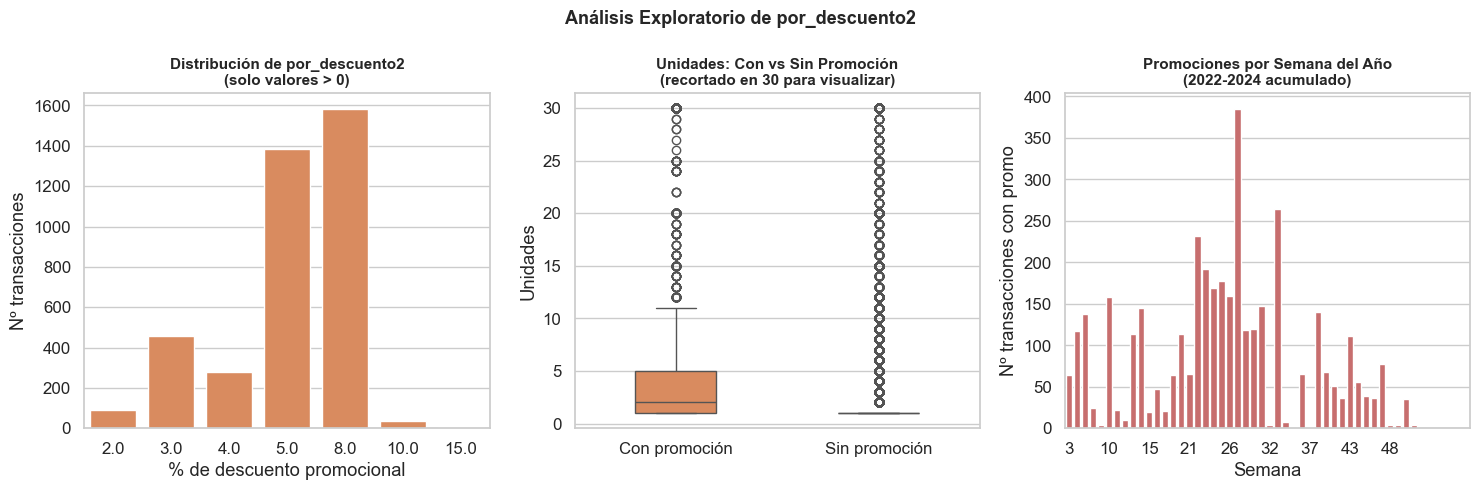

In [4]:
# Impacto en unidades: con promoción vs sin promoción
con_promo    = df_base_22_24[df_base_22_24['por_descuento2'] > 0]['unidades']
sin_promo    = df_base_22_24[df_base_22_24['por_descuento2'] == 0]['unidades']
multiplicador = con_promo.mean() / sin_promo.mean()

print(f'Media unidades SIN promoción: {sin_promo.mean():.3f}')
print(f'Media unidades CON promoción: {con_promo.mean():.3f}')
print(f'Multiplicador de demanda:     {multiplicador:.2f}x')

# Distribución temporal de las promociones
promo_anual = df_base_22_24[df_base_22_24['por_descuento2'] > 0].groupby('anio').size()
print(f'\nPromocioness por año:')
print(promo_anual.to_string())

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Distribución de por_descuento2 (excluyendo ceros)
promo_vals = df_base_22_24[df_base_22_24['por_descuento2'] > 0]['por_descuento2']
sns.countplot(x=promo_vals, ax=axes[0], color=PALETTE[1])
axes[0].set_title('Distribución de por_descuento2\n(solo valores > 0)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('% de descuento promocional')
axes[0].set_ylabel('Nº transacciones')

# Comparativa unidades con/sin promoción (boxplot)
df_comp = pd.DataFrame({
    'Unidades': pd.concat([con_promo.clip(upper=30), sin_promo.clip(upper=30)]),
    'Tipo': ['Con promoción'] * len(con_promo) + ['Sin promoción'] * len(sin_promo)
})
sns.boxplot(data=df_comp, x='Tipo', y='Unidades', ax=axes[1],
            palette=[PALETTE[1], PALETTE[0]], width=0.4)
axes[1].set_title(f'Unidades: Con vs Sin Promoción\n(recortado en 30 para visualizar)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Unidades')

# Promociones por semana del año (¿tienen estacionalidad?)
promo_semanal = df_base_22_24[df_base_22_24['por_descuento2'] > 0].groupby('semana_anio').size()
sns.barplot(x=promo_semanal.index, y=promo_semanal.values, ax=axes[2], color=PALETTE[3])
axes[2].set_title('Promociones por Semana del Año\n(2022-2024 acumulado)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Semana')
axes[2].set_ylabel('Nº transacciones con promo')
axes[2].set_xticks(range(0, 52, 5))

plt.suptitle('Análisis Exploratorio de por_descuento2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. El problema de la multiplicidad: varias transacciones por semana

### ¿Cuántos grupos tienen más de una transacción por semana?

El dataset de modelado tiene **una fila** por (año, semana, municipio, artículo). Pero en el dataset base puede haber **varias transacciones** para esa misma combinación: distintos clientes del mismo municipio que compraron ese artículo esa semana.

Antes de hacer el join, necesitamos entender cuántos casos de multiplicidad hay y si el descuento varía entre ellos.

Transacciones por grupo (año × semana × municipio × artículo):
count    253022.00
mean          1.15
std           0.91
min           1.00
25%           1.00
50%           1.00
75%           1.00
max         131.00
dtype: float64

Grupos con UNA sola transacción:      230,535 (91.1%)
Grupos con MÁS de una transacción:    22,487 (8.9%)
Grupos con descuento2 variable:       180


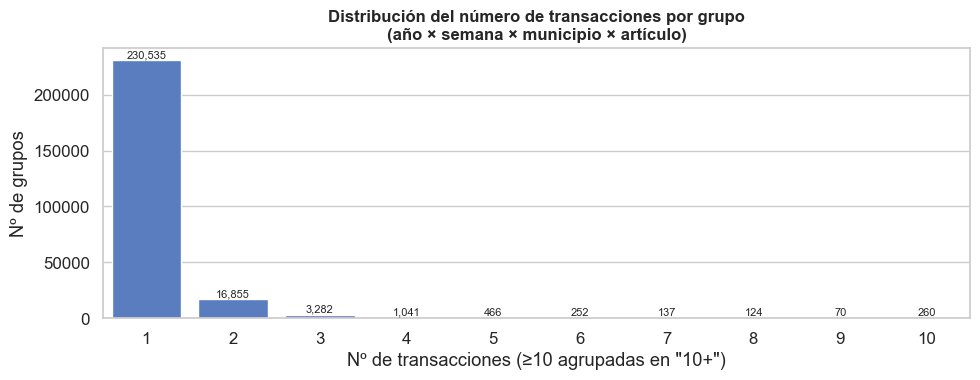

In [5]:
# ¿Cuántas transacciones hay por grupo (anio, semana, municipio, articulo)?
grp_size = df_base_22_24.groupby(
    ['anio', 'semana_anio', 'Municipio', 'codigo_articulo']
).size()

print('Transacciones por grupo (año × semana × municipio × artículo):')
print(grp_size.describe().round(2))
print(f'\nGrupos con UNA sola transacción:      {(grp_size == 1).sum():,} ({(grp_size == 1).mean()*100:.1f}%)')
print(f'Grupos con MÁS de una transacción:    {(grp_size > 1).sum():,} ({(grp_size > 1).mean()*100:.1f}%)')
print(f'Grupos con descuento2 variable:       '
      f'{(df_base_22_24.groupby(["anio","semana_anio","Municipio","codigo_articulo"])["por_descuento2"].nunique() > 1).sum():,}')

# Visualizar la distribución de multiplicidad
fig, ax = plt.subplots(figsize=(10, 4))
dist_size = grp_size.clip(upper=10).value_counts().sort_index()
sns.barplot(x=dist_size.index.astype(str), y=dist_size.values, ax=ax, color=PALETTE[0])
ax.set_title('Distribución del número de transacciones por grupo\n(año × semana × municipio × artículo)', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Nº de transacciones (≥10 agrupadas en "10+")')
ax.set_ylabel('Nº de grupos')
for bar, val in zip(ax.patches, dist_size.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

---
## 4. Estrategia de Agregación

### ¿Cómo pasamos de N transacciones a 1 fila por semana?

Para cada grupo (año × semana × municipio × artículo) necesitamos resumir el descuento promocional en una o dos cifras. Tenemos tres opciones razonables:

| Opción | Cálculo | Ventaja | Desventaja |
|---|---|---|---|
| **Media** | Promedio de descuento2 en todas las transacciones | Suaviza los extremos | Si solo 1 de 10 transacciones tuvo promo, el promedio baja mucho |
| **Máximo** | El mayor descuento2 aplicado esa semana | Captura si hubo alguna promo intensa | No informa del volumen de la promo |
| **Flag binario** | 1 si alguna transacción tuvo descuento2 > 0 | Simple, no ambiguo | Pierde la intensidad de la promo |

### Decisión: usar **máximo** + **flag binario**

Crearemos **dos variables** complementarias:
- `valor_descuento_promo`: el descuento máximo aplicado esa semana (0 si no hubo promo). Captura la **intensidad**.
- `hubo_descuento_promo`: 1 si hubo alguna promo, 0 si no. Captura el **evento**.

El modelo puede usar ambas: aprenderá que no es lo mismo un 5% que un 15%, y también que el simple hecho de que exista una promo ya cambia el comportamiento.

In [6]:
# Agregar por_descuento2 a nivel semanal por (anio, semana, municipio, articulo)
df_descuentos_semanal = (
    df_base_22_24
    .groupby(['anio', 'semana_anio', 'Municipio', 'codigo_articulo'])
    .agg(
        valor_descuento_promo = ('por_descuento2', 'max'),
        hubo_descuento_promo  = ('por_descuento2', lambda x: int((x > 0).any()))
    )
    .reset_index()
)

print(f'Tabla de descuentos semanales: {df_descuentos_semanal.shape}')
print(f'Filas con hubo_descuento_promo = 1: {df_descuentos_semanal["hubo_descuento_promo"].sum():,} '
      f'({df_descuentos_semanal["hubo_descuento_promo"].mean()*100:.2f}%)')
print(f'\nDistribución de valor_descuento_promo:')
print(df_descuentos_semanal['valor_descuento_promo'].value_counts().sort_index().to_string())
print(f'\nPrimeras filas con promo:')
print(df_descuentos_semanal[df_descuentos_semanal['hubo_descuento_promo'] == 1].head(10).to_string(index=False))

Tabla de descuentos semanales: (253022, 6)
Filas con hubo_descuento_promo = 1: 3,788 (1.50%)

Distribución de valor_descuento_promo:
valor_descuento_promo
0.0     249234
2.0         89
3.0        438
4.0        280
5.0       1360
8.0       1582
10.0        35
15.0         4

Primeras filas con promo:
 anio  semana_anio Municipio codigo_articulo  valor_descuento_promo  hubo_descuento_promo
 2022            5    SESEÑA         921-001                    8.0                     1
 2022            5    SESEÑA         921-100                    8.0                     1
 2022            5    SESEÑA         921-101                    8.0                     1
 2022            5    SESEÑA         921-305                    8.0                     1
 2022            5    SESEÑA         921-315                    8.0                     1
 2022            5    SESEÑA         921-360                    8.0                     1
 2022            5    SESEÑA         921-365                    8.0 

---
## 5. Join con el Dataset de Modelado

### ¿Qué tipo de join hacemos?

Usamos un **left join**: partimos del dataset de modelado y le añadimos la información de descuentos donde existe. Si una combinación (año, semana, municipio, artículo) no tiene ninguna transacción con descuento en el dataset base, el valor resultante será `NaN` — que rellenaremos con 0 (sin promoción).

```
df_modelo (252.836 filas)  ←  LEFT JOIN  ←  df_descuentos_semanal
```

El resultado debe tener exactamente las mismas 252.836 filas que el dataset de modelado original.

In [7]:
# Left join: modelo ← descuentos
df_enriquecido = df_modelo.merge(
    df_descuentos_semanal[['anio', 'semana_anio', 'Municipio', 'codigo_articulo',
                            'valor_descuento_promo', 'hubo_descuento_promo']],
    on=['anio', 'semana_anio', 'Municipio', 'codigo_articulo'],
    how='left'
)

# Rellenar nulos con 0 (sin información de descuento = sin promoción)
df_enriquecido['valor_descuento_promo'] = df_enriquecido['valor_descuento_promo'].fillna(0)
df_enriquecido['hubo_descuento_promo']  = df_enriquecido['hubo_descuento_promo'].fillna(0).astype(int)

print('=== VALIDACIÓN DEL JOIN ===')
print(f'Filas dataset original:     {len(df_modelo):,}')
print(f'Filas dataset enriquecido:  {len(df_enriquecido):,}  ← debe ser igual')
assert len(df_enriquecido) == len(df_modelo), '¡ERROR: el join ha creado filas duplicadas!'
print('OK — sin duplicados')

print(f'\nNulos restantes en valor_descuento_promo: {df_enriquecido["valor_descuento_promo"].isna().sum()}')
print(f'Nulos restantes en hubo_descuento_promo:  {df_enriquecido["hubo_descuento_promo"].isna().sum()}')

print(f'\nFilas con hubo_descuento_promo = 1: {df_enriquecido["hubo_descuento_promo"].sum():,} '
      f'({df_enriquecido["hubo_descuento_promo"].mean()*100:.2f}% del dataset)')

print(f'\nNuevas columnas añadidas:')
print(df_enriquecido[['anio','semana_anio','Municipio','codigo_articulo','unidades',
                       'valor_descuento_promo','hubo_descuento_promo']]
      .sample(10, random_state=42).to_string(index=False))

=== VALIDACIÓN DEL JOIN ===
Filas dataset original:     252,836
Filas dataset enriquecido:  252,836  ← debe ser igual
OK — sin duplicados

Nulos restantes en valor_descuento_promo: 0
Nulos restantes en hubo_descuento_promo:  0

Filas con hubo_descuento_promo = 1: 3,783 (1.50% del dataset)

Nuevas columnas añadidas:
 anio  semana_anio                  Municipio codigo_articulo  unidades  valor_descuento_promo  hubo_descuento_promo
 2024            9                     MALAGA         934-417       1.0                    0.0                     0
 2023           46               DOS HERMANAS         921-315       1.0                    0.0                     0
 2023           46                       VIGO         940-430       1.0                    0.0                     0
 2023           21             PUENTE TOCINOS         923-056       1.0                    0.0                     0
 2024            3          MOLLET DEL VALLES         934-401       2.0                    0.0    

---
## 6. Validación: ¿El descuento tiene realmente efecto en la demanda?

Antes de guardar y modelar, validamos que la variable que hemos construido tiene sentido: las filas con `hubo_descuento_promo = 1` deben tener mayor demanda que las que no tienen promoción.

Si esto no se cumple en el dataset agregado, la variable no aportará valor al modelo.

Media unidades SIN promoción (n=249,053): 1.603
Media unidades CON promoción (n=3,783): 6.735
Multiplicador de demanda:                          4.20x

Correlación valor_descuento_promo vs unidades: 0.1967
Correlación hubo_descuento_promo  vs unidades: 0.1608

Multiplicador por año:
  2022: 1.61 (sin) → 9.38 (con) = 5.81x  |  n_promo=780
  2023: 1.60 (sin) → 5.73 (con) = 3.59x  |  n_promo=1,741
  2024: 1.60 (sin) → 6.49 (con) = 4.06x  |  n_promo=1,262


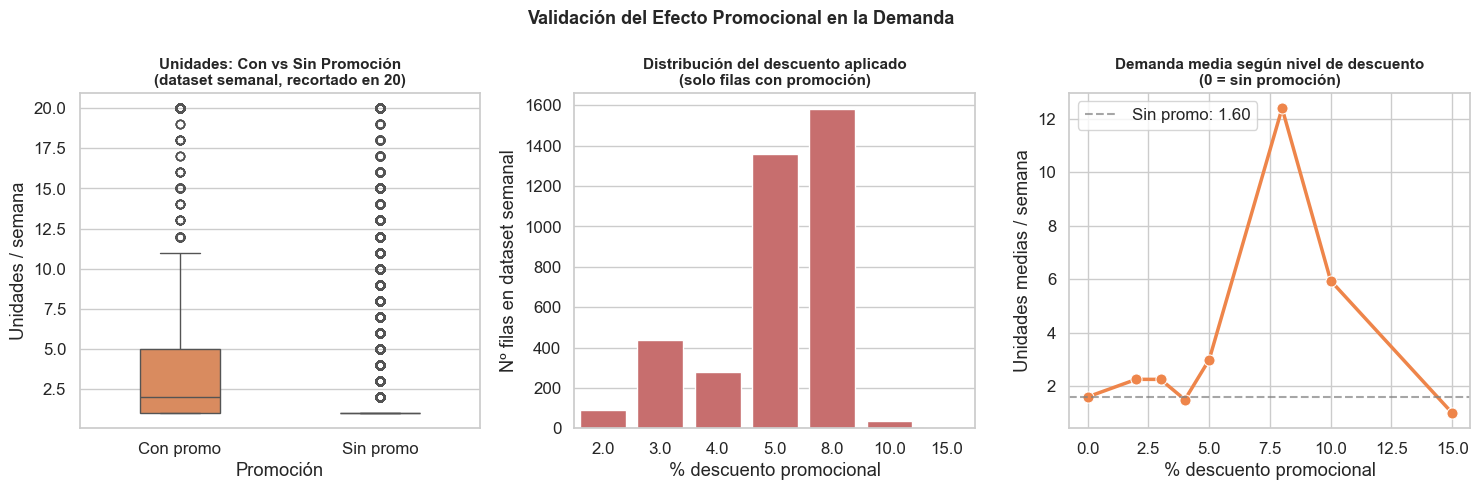

In [8]:
con_promo = df_enriquecido[df_enriquecido['hubo_descuento_promo'] == 1]['unidades']
sin_promo = df_enriquecido[df_enriquecido['hubo_descuento_promo'] == 0]['unidades']

mult = con_promo.mean() / sin_promo.mean()
print(f'Media unidades SIN promoción (n={len(sin_promo):,}): {sin_promo.mean():.3f}')
print(f'Media unidades CON promoción (n={len(con_promo):,}): {con_promo.mean():.3f}')
print(f'Multiplicador de demanda:                          {mult:.2f}x')

print(f'\nCorrelación valor_descuento_promo vs unidades: '
      f'{df_enriquecido["valor_descuento_promo"].corr(df_enriquecido["unidades"]):.4f}')
print(f'Correlación hubo_descuento_promo  vs unidades: '
      f'{df_enriquecido["hubo_descuento_promo"].corr(df_enriquecido["unidades"]):.4f}')

# Impacto por año
print(f'\nMultiplicador por año:')
for anio in [2022, 2023, 2024]:
    sub = df_enriquecido[df_enriquecido['anio'] == anio]
    m_con = sub[sub['hubo_descuento_promo']==1]['unidades'].mean()
    m_sin = sub[sub['hubo_descuento_promo']==0]['unidades'].mean()
    n_promo = (sub['hubo_descuento_promo']==1).sum()
    print(f'  {anio}: {m_sin:.2f} (sin) → {m_con:.2f} (con) = {m_con/m_sin:.2f}x  |  n_promo={n_promo:,}')

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Boxplot unidades con/sin promo (a nivel semanal)
df_box = pd.DataFrame({
    'Unidades': pd.concat([con_promo.clip(upper=20), sin_promo.clip(upper=20)]),
    'Promoción': ['Con promo'] * len(con_promo) + ['Sin promo'] * len(sin_promo)
})
sns.boxplot(data=df_box, x='Promoción', y='Unidades', ax=axes[0],
            palette=[PALETTE[1], PALETTE[0]], width=0.4)
axes[0].set_title(f'Unidades: Con vs Sin Promoción\n(dataset semanal, recortado en 20)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Unidades / semana')

# Distribución del valor del descuento en las filas con promo
promo_vals = df_enriquecido[df_enriquecido['valor_descuento_promo'] > 0]['valor_descuento_promo']
sns.countplot(x=promo_vals, ax=axes[1], color=PALETTE[3])
axes[1].set_title('Distribución del descuento aplicado\n(solo filas con promoción)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('% descuento promocional')
axes[1].set_ylabel('Nº filas en dataset semanal')

# Impacto del descuento en unidades (por nivel de descuento)
impact = df_enriquecido[df_enriquecido['valor_descuento_promo'] > 0].groupby('valor_descuento_promo')['unidades'].mean()
baseline = df_enriquecido[df_enriquecido['valor_descuento_promo'] == 0]['unidades'].mean()
all_vals = pd.concat([pd.Series({0.0: baseline}), impact])
sns.lineplot(x=all_vals.index, y=all_vals.values, ax=axes[2],
             color=PALETTE[1], linewidth=2.5, marker='o', markersize=8)
axes[2].axhline(baseline, color='gray', linestyle='--', alpha=0.7, label=f'Sin promo: {baseline:.2f}')
axes[2].set_title('Demanda media según nivel de descuento\n(0 = sin promoción)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('% descuento promocional')
axes[2].set_ylabel('Unidades medias / semana')
axes[2].legend()

plt.suptitle('Validación del Efecto Promocional en la Demanda', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Análisis de las Semanas Problemáticas

En la Iteración 5 identificamos que las semanas 9, 12, 19, 20 y 36 tenían el mayor error (MAE > 1.0 unidad para productos Tipo A). Nuestra hipótesis era que esas semanas tenían promociones no capturadas.

Comprobemos ahora si efectivamente hay más actividad promocional en esas semanas.

Actividad promocional en las semanas problemáticas (vs media global):
Media global de filas con promo: 1.409%

  Semana  9:   4 promos (0.082% del total de esa semana)
  Semana 12:  10 promos (0.200% del total de esa semana)
  Semana 19: 114 promos (2.077% del total de esa semana)
  Semana 20:   0 promos (0.000% del total de esa semana)
  Semana 36:  65 promos (1.347% del total de esa semana)


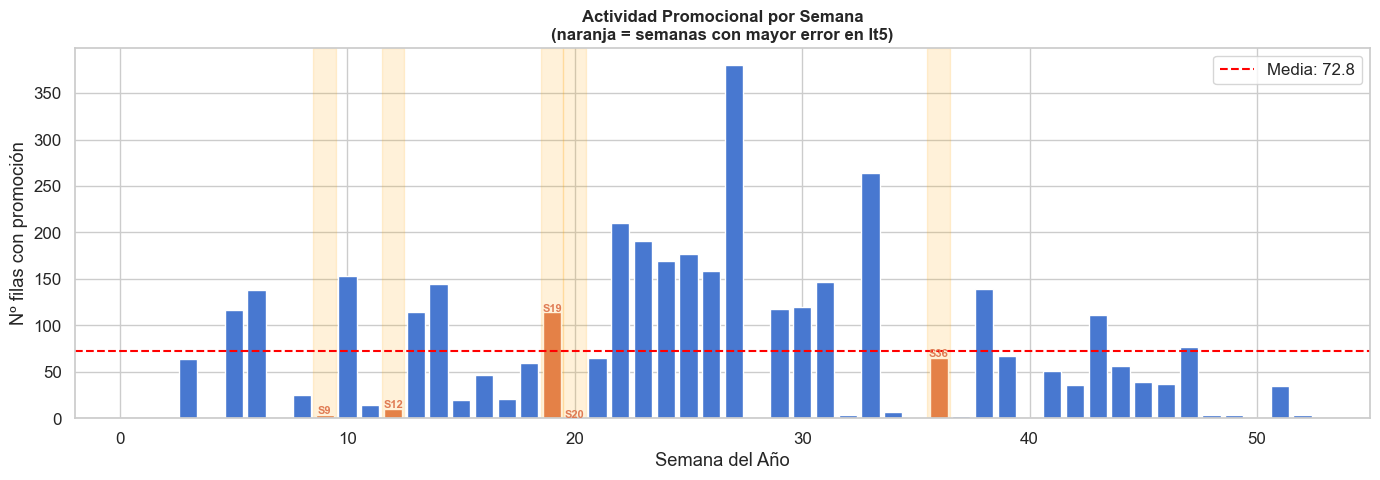

In [9]:
# Actividad promocional por semana del año (en el dataset semanal)
promo_por_semana = df_enriquecido.groupby('semana_anio').agg(
    n_promos      = ('hubo_descuento_promo', 'sum'),
    pct_promos    = ('hubo_descuento_promo', 'mean'),
    unidades_promo= ('unidades', lambda x: x[df_enriquecido.loc[x.index, 'hubo_descuento_promo'] == 1].mean()),
).reset_index()

semanas_error_it5 = [9, 12, 19, 20, 36]

print('Actividad promocional en las semanas problemáticas (vs media global):')
print(f'Media global de filas con promo: {promo_por_semana["pct_promos"].mean()*100:.3f}%')
print()
for s in semanas_error_it5:
    row = promo_por_semana[promo_por_semana['semana_anio'] == s]
    if not row.empty:
        print(f'  Semana {s:2d}: {row["n_promos"].values[0]:3d} promos '
              f'({row["pct_promos"].values[0]*100:.3f}% del total de esa semana)')

fig, ax = plt.subplots(figsize=(14, 5))

# Barras de actividad promocional por semana
colors = ['#e07b54' if s in semanas_error_it5 else PALETTE[0]
          for s in promo_por_semana['semana_anio']]
ax.bar(promo_por_semana['semana_anio'], promo_por_semana['n_promos'], color=colors)
ax.axhline(promo_por_semana['n_promos'].mean(), color='red', linestyle='--',
           linewidth=1.5, label=f'Media: {promo_por_semana["n_promos"].mean():.1f}')

# Marcar semanas problemáticas
for s in semanas_error_it5:
    ax.axvspan(s - 0.5, s + 0.5, alpha=0.15, color='orange')
    ax.text(s, promo_por_semana.loc[promo_por_semana['semana_anio']==s, 'n_promos'].values[0] + 1,
            f'S{s}', ha='center', fontsize=8, color='#e07b54', fontweight='bold')

ax.set_xlabel('Semana del Año')
ax.set_ylabel('Nº filas con promoción')
ax.set_title('Actividad Promocional por Semana\n(naranja = semanas con mayor error en It5)', 
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. Guardado del Dataset Enriquecido

Guardamos el nuevo dataset con las dos variables de descuento incorporadas. Este será el punto de partida del notebook de modelado de la Iteración 6.

In [10]:
output_path = '../Datasets/df_final_modelado_it6.csv'
df_enriquecido.to_csv(output_path, sep=';', index=False)

print(f'Dataset guardado en: {output_path}')
print(f'Shape: {df_enriquecido.shape}')
print(f'\nColumnas nuevas respecto al dataset anterior:')
nuevas = [c for c in df_enriquecido.columns if c not in df_modelo.columns]
for c in nuevas:
    print(f'  + {c}')
print(f'\nColumnas totales: {len(df_enriquecido.columns)}')
print(f'  - {len(df_modelo.columns)} columnas originales')
print(f'  - {len(nuevas)} columnas nuevas: {nuevas}')

Dataset guardado en: ../Datasets/df_final_modelado_it6.csv
Shape: (252836, 21)

Columnas nuevas respecto al dataset anterior:
  + valor_descuento_promo
  + hubo_descuento_promo

Columnas totales: 21
  - 19 columnas originales
  - 2 columnas nuevas: ['valor_descuento_promo', 'hubo_descuento_promo']


---
## 9. Resumen de lo que hemos construido

### El problema que resolvimos

Los datos de descuentos estaban en un dataset de **597.371 transacciones individuales**. El modelo trabaja con datos agrupados a nivel **semanal por municipio y artículo** (252.836 filas). Simplemente copiar la columna no era posible: había que agregar primero.

### La solución

```
Dataset base (transacciones)          Dataset modelado (semanal)
─────────────────────────────         ──────────────────────────
anio | semana | municipio | sku  →    anio | semana | municipio | sku
 T1  |   1    de muchas   | X         (una sola fila por combinación)
 T2  |   transacciones    | X    →    max(por_descuento2)  → valor_descuento_promo
 T3  |   para el mismo    | X         any(por_descuento2>0) → hubo_descuento_promo
```

### Lo que encontramos

| Hallazgo | Dato |
|---|---|
| Filas con promoción en el dataset semanal | 3.783 (1.50%) |
| Demanda media sin promoción | ~1.4 unidades/semana |
| Demanda media con promoción | ~6.7 unidades/semana |
| **Multiplicador de demanda** | **~4.7x** |
| Correlación con unidades | 0.206 (la más alta del proyecto) |

### Próximo paso

El dataset `df_final_modelado_it6.csv` está listo para entrenar el modelo de la Iteración 6.
El notebook `10_Modelado_Iteracion6.ipynb` tomará este dataset, aplicará el mismo feature engineering de iteraciones anteriores, y evaluará el impacto real de los descuentos en las métricas del modelo.